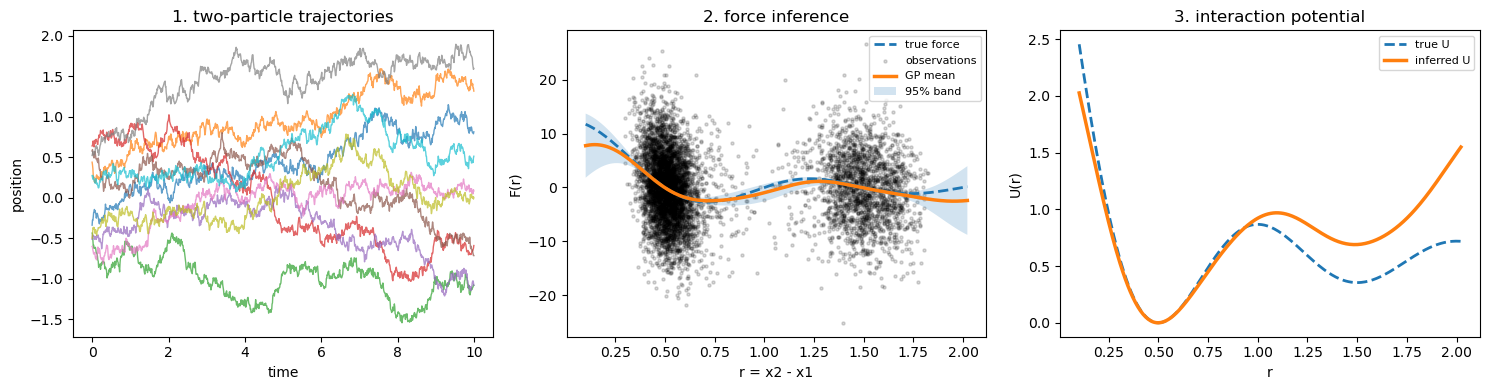

Saved figure: two_particle_reciprocal_gp.png
number of trajectories: 5
number of GP observations: 7000
r range: 0.30170482583811387 1.821835150777567
obs noise std: 6.324555320336759


In [147]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# ============================================================
# Parameters
# ============================================================

dt = 0.01
n_steps = 1000
n_traj = 5

D = 0.05
kT = 0.10

particle_diameter = 0.15

# ============================================================
# Reciprocal interaction force
# ============================================================

def true_force(r):

    r = np.asarray(r, dtype=float)

    r_safe = np.where(np.abs(r) < 1e-6, 1e-6, r)

    # oscillatory interaction
    F = 2 * np.sin(2*np.pi*r_safe) / r_safe

    return F

# ============================================================
# Simulate TWO particles
# hard-core: x2 > x1
# ============================================================

def simulate_two_particles(x1_0, x2_0, seed):

    np.random.seed(seed)

    x1 = np.zeros(n_steps)
    x2 = np.zeros(n_steps)

    x1[0] = x1_0
    x2[0] = x2_0

    for t in range(n_steps - 1):

        r = x2[t] - x1[t]

        # reciprocal force
        F12 = true_force(r)

        # overdamped drift
        drift1 = -(D/kT) * F12 * dt
        drift2 = +(D/kT) * F12 * dt

        # Brownian noise
        noise1 = np.sqrt(2*D*dt) * np.random.randn()
        noise2 = np.sqrt(2*D*dt) * np.random.randn()

        x1_new = x1[t] + drift1 + noise1
        x2_new = x2[t] + drift2 + noise2

        # hard-core exclusion
        if (x2_new - x1_new) < particle_diameter:

            midpoint = 0.5 * (x1_new + x2_new)

            x1_new = midpoint - particle_diameter/2
            x2_new = midpoint + particle_diameter/2

        x1[t+1] = x1_new
        x2[t+1] = x2_new

    return x1, x2

# ============================================================
# Build GP training observations
#
# IMPORTANT:
# use BOTH particle trajectories
# ============================================================

def extract_force_observations(x1, x2, dt, D, kT):

    r = x2[:-1] - x1[:-1]

    dx1 = np.diff(x1)
    dx2 = np.diff(x2)

    # particle 1 feels -F(r)
    F_obs_1 = -(dx1/dt) * (kT/D)

    # particle 2 feels +F(r)
    F_obs_2 = +(dx2/dt) * (kT/D)

    # combine BOTH observations
    x_obs = np.concatenate([r, r])

    y_obs = np.concatenate([F_obs_1, F_obs_2])

    return x_obs, y_obs

# ============================================================
# GP kernel
# ============================================================

def build_K(r1, r2, ell=0.25, sigma=5.0):

    r1 = np.asarray(r1)
    r2 = np.asarray(r2)

    diff = r1[:, None] - r2[None, :]

    return sigma**2 * np.exp(
        -0.5 * (diff / ell)**2
    )

# ============================================================
# GP posterior
# ============================================================

def gp_posterior(
    x_train,
    y_train,
    x_test,
    ell=0.25,
    sigma=5.0,
    noise_std=2.0
):

    K_tt = build_K(x_train, x_train, ell, sigma)

    K_noisy = (
        K_tt
        + (noise_std**2 + 1e-6)
        * np.eye(len(x_train))
    )

    alpha = np.linalg.solve(K_noisy, y_train)

    K_st = build_K(x_test, x_train, ell, sigma)

    mean = K_st @ alpha

    v = np.linalg.solve(K_noisy, K_st.T)

    var = sigma**2 - np.sum(K_st * v.T, axis=1)

    std = np.sqrt(np.maximum(var, 0))

    return mean, std

# ============================================================
# Integrate force -> potential
# ============================================================

def integrate_force_to_potential(r_grid, F):

    U = np.zeros_like(F)

    for i in range(1, len(r_grid)):

        dr = r_grid[i] - r_grid[i-1]

        U[i] = (
            U[i-1]
            - 0.5 * (F[i] + F[i-1]) * dr
        )

    U -= U.min()

    return U

# ============================================================
# Generate trajectories
# ============================================================

all_x1 = []
all_x2 = []

all_x_obs = []
all_y_obs = []

for i in range(n_traj):

    x1_0 = -0.5 + 0.1*np.random.randn()
    x2_0 = +0.5 + 0.1*np.random.randn()

    x1, x2 = simulate_two_particles(
        x1_0,
        x2_0,
        seed=i+1
    )

    x_obs_i, y_obs_i = extract_force_observations(
        x1,
        x2,
        dt,
        D,
        kT
    )

    all_x1.append(x1)
    all_x2.append(x2)

    all_x_obs.append(x_obs_i)
    all_y_obs.append(y_obs_i)

x_obs = np.concatenate(all_x_obs)
y_obs = np.concatenate(all_y_obs)

# ============================================================
# Downsample
# ============================================================

max_points = 7000

if len(x_obs) > max_points:

    idx = np.random.choice(
        len(x_obs),
        size=max_points,
        replace=False
    )

    x_obs = x_obs[idx]
    y_obs = y_obs[idx]

# ============================================================
# GP inference
# ============================================================

margin = 0.2

r_grid = np.linspace(
    x_obs.min() - margin,
    x_obs.max() + margin,
    300
)

# single-particle estimator noise
obs_noise_std = kT * np.sqrt(2.0 / (D * dt))

F_mean, F_std = gp_posterior(
    x_obs,
    y_obs,
    r_grid,
    ell=0.25,
    sigma=5.0,
    noise_std=obs_noise_std
)

# ============================================================
# Potentials
# ============================================================

U_true = integrate_force_to_potential(
    r_grid,
    true_force(r_grid)
)

U_inferred = integrate_force_to_potential(
    r_grid,
    F_mean
)

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# ------------------------------------------------
# particle trajectories
# ------------------------------------------------

for i in range(n_traj):

    t = np.arange(n_steps) * dt

    axes[0].plot(
        t,
        all_x1[i],
        alpha=0.7,
        lw=1
    )

    axes[0].plot(
        t,
        all_x2[i],
        alpha=0.7,
        lw=1
    )

axes[0].set_xlabel('time')
axes[0].set_ylabel('position')
axes[0].set_title('1. two-particle trajectories')

# ------------------------------------------------
# force inference
# ------------------------------------------------

axes[1].plot(
    r_grid,
    true_force(r_grid),
    '--',
    lw=2,
    label='true force'
)

# noisy observations
axes[1].scatter(
    x_obs,
    y_obs,
    s=5,
    alpha=0.15,
    color='black',
    label='observations'
)

axes[1].plot(
    r_grid,
    F_mean,
    lw=2.5,
    label='GP mean'
)

axes[1].fill_between(
    r_grid,
    F_mean - 1.96*F_std,
    F_mean + 1.96*F_std,
    alpha=0.2,
    label='95% band'
)

axes[1].set_xlabel('r = x2 - x1')
axes[1].set_ylabel('F(r)')
axes[1].set_title('2. force inference')
axes[1].legend(fontsize=8)

# ------------------------------------------------
# potential
# ------------------------------------------------

axes[2].plot(
    r_grid,
    U_true,
    '--',
    lw=2,
    label='true U'
)

axes[2].plot(
    r_grid,
    U_inferred,
    lw=2.5,
    label='inferred U'
)
axes[2].set_xlabel('r')
axes[2].set_ylabel('U(r)')
axes[2].set_title('3. interaction potential')
axes[2].legend(fontsize=8)

plt.tight_layout()

fig_name = 'two_particle_reciprocal_gp.png'

plt.savefig(fig_name, dpi=150)

plt.show()

print('Saved figure:', fig_name)
print('number of trajectories:', n_traj)
print('number of GP observations:', len(x_obs))
print('r range:', x_obs.min(), x_obs.max())
print('obs noise std:', obs_noise_std)